## Week 7: 

## 1. ARCH and GARCH Models
## 2. Out of Sample Forecasting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from scipy.stats.distributions import chi2

from statsmodels.tsa.arima.model import ARIMA

In [2]:
spdata = pd.read_csv('data7_SP500.csv', header = 0, index_col = 0,  na_values =".")
spdata.index = pd.to_datetime(spdata.index)
spdata = spdata.ffill()
spdata = spdata['2013':'2022']
spdata.columns = ['price']
spdata.head(3)

,price
DATE,
2013-03-04,1525.20
2013-03-05,1539.79
2013-03-06,1541.46


In [5]:
spdata['ret'] = spdata.price.pct_change() * 100
spdata['sqret'] = spdata.ret.mul(spdata.ret)

In [7]:
spdata.head(3)

,price,ret,sqret
DATE,,,
2013-03-04,1525.20,NaN,NaN
2013-03-05,1539.79,0.956596,0.915076
2013-03-06,1541.46,0.108456,0.011763


Text(0.5, 1.0, 'SP 500 Returns')

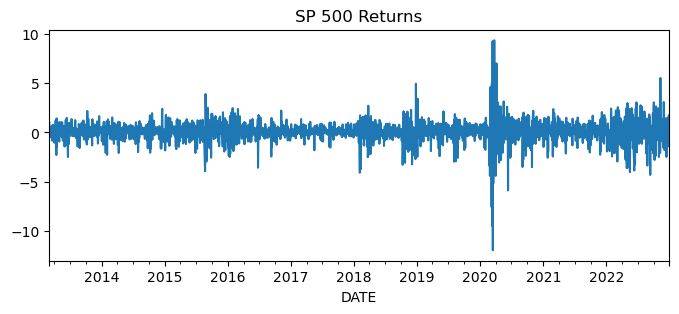

In [9]:
spdata.ret.plot(figsize =(8,3))
plt.title("SP 500 Returns")

Text(0.5, 1.0, 'SP 500 Volatility')

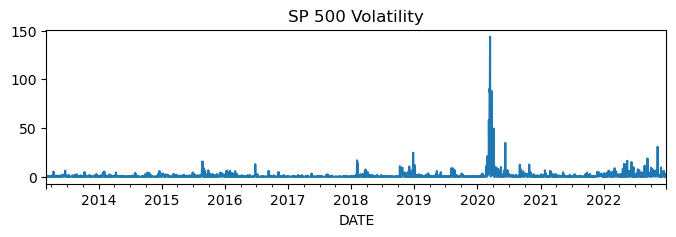

In [11]:
spdata.sqret.plot(figsize =(8,2))
plt.title("SP 500 Volatility")

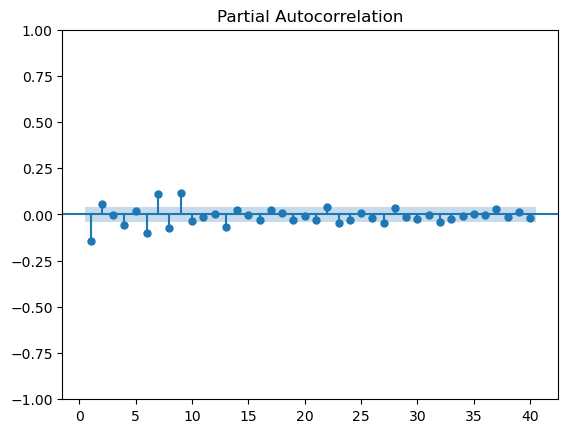

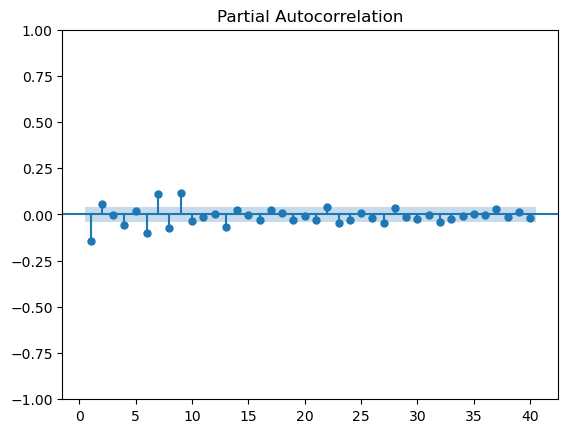

In [13]:
sgt.plot_pacf(spdata.ret[1:], lags = 40, zero = False)

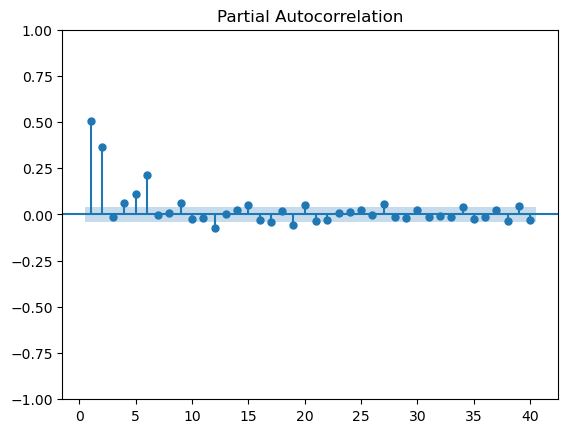

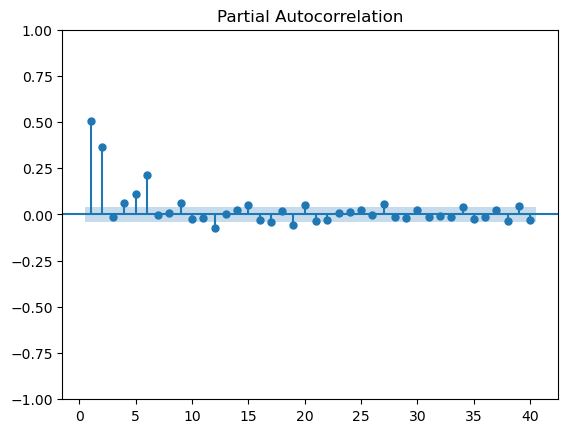

In [15]:
sgt.plot_pacf(spdata.sqret[1:], lags = 40, zero = False)

In [17]:
pip install arch 

Note: you may need to restart the kernel to use updated packages.


In [19]:
from arch import arch_model

In [21]:
model_arch1 = arch_model(spdata.ret[1:], mean = 'Constant', vol = 'ARCH', p = 1)
res_arch1 = model_arch1.fit(update_freq = 1)
res_arch1.summary()

Iteration:      1,   Func. Count:      5,   Neg. LLF: 19040.372521085526
Iteration:      2,   Func. Count:     14,   Neg. LLF: 5955.427562479732
Iteration:      3,   Func. Count:     21,   Neg. LLF: 3543.8208159376927
Iteration:      4,   Func. Count:     27,   Neg. LLF: 3509.5296531056733
Iteration:      5,   Func. Count:     31,   Neg. LLF: 3509.5295264204547
Iteration:      6,   Func. Count:     34,   Neg. LLF: 3509.5295264204888
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3509.5295264204547
            Iterations: 6
            Function evaluations: 34
            Gradient evaluations: 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                    ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -3509.53
Distribution:                  Normal   AIC:                           7025.06
Method:            Maximum Likelihood   BIC:                           7042.61
                                        No. Observations:                 2564
Date:                Sun, Mar 09 2025   Df Residuals:                     2563
Time:                        22:00:27   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0972  1.891e-02      5.142  2.721e-07 [6.015e-02,  0.134]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          0.6056  4.262e-02     14.211  7.875e-46 [  0.522,  0.689]
alpha[1]       0.5232  8.394e-02      6.234  4.560e-10 [  0.359,  0.688]
========================================================================

Covariance estimator: robust
"""

In [23]:
model_arch1 = arch_model(spdata.ret[1:], mean = 'Constant', vol = 'ARCH', p = 2)
res_arch1 = model_arch1.fit(update_freq = 1)
res_arch1.summary()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 112582.97520186173
Iteration:      2,   Func. Count:     15,   Neg. LLF: 588078.5515135544
Iteration:      3,   Func. Count:     22,   Neg. LLF: 7631.664929767159
Iteration:      4,   Func. Count:     29,   Neg. LLF: 3361.54556814926
Iteration:      5,   Func. Count:     35,   Neg. LLF: 3343.2094271635615
Iteration:      6,   Func. Count:     40,   Neg. LLF: 3343.206098479853
Iteration:      7,   Func. Count:     46,   Neg. LLF: 3343.1964270378303
Iteration:      8,   Func. Count:     51,   Neg. LLF: 3343.1963945056273
Iteration:      9,   Func. Count:     55,   Neg. LLF: 3343.196394505643
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3343.1963945056273
            Iterations: 9
            Function evaluations: 55
            Gradient evaluations: 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                    ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -3343.20
Distribution:                  Normal   AIC:                           6694.39
Method:            Maximum Likelihood   BIC:                           6717.79
                                        No. Observations:                 2564
Date:                Sun, Mar 09 2025   Df Residuals:                     2563
Time:                        22:00:31   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0849  1.656e-02      5.128  2.927e-07 [5.247e-02,  0.117]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          0.3996  3.298e-02     12.117  8.546e-34 [  0.335,  0.464]
alpha[1]       0.3490  5.493e-02      6.354  2.093e-10 [  0.241,  0.457]
alpha[2]       0.3372  4.862e-02      6.936  4.033e-12 [  0.242,  0.433]
========================================================================

Covariance estimator: robust
"""

In [25]:
model_arch1 = arch_model(spdata.ret[1:], mean = 'Constant', vol = 'ARCH', p = 7)
res_arch1 = model_arch1.fit(update_freq = 1)
res_arch1.summary()

Iteration:      1,   Func. Count:     11,   Neg. LLF: 18696.155972504617
Iteration:      2,   Func. Count:     26,   Neg. LLF: 6083.549759818088
Iteration:      3,   Func. Count:     39,   Neg. LLF: 5724.975549175916
Iteration:      4,   Func. Count:     50,   Neg. LLF: 3682.683041999348
Iteration:      5,   Func. Count:     61,   Neg. LLF: 4286.451858546032
Iteration:      6,   Func. Count:     72,   Neg. LLF: 3964.3799511896914
Iteration:      7,   Func. Count:     83,   Neg. LLF: 3316.8264789020077
Iteration:      8,   Func. Count:     94,   Neg. LLF: 3387.9136752541044
Iteration:      9,   Func. Count:    106,   Neg. LLF: 3409.9092738214745
Iteration:     10,   Func. Count:    117,   Neg. LLF: 3283.4080517984066
Iteration:     11,   Func. Count:    128,   Neg. LLF: 3191.4046062621833
Iteration:     12,   Func. Count:    139,   Neg. LLF: 3351.515517886629
Iteration:     13,   Func. Count:    150,   Neg. LLF: 3177.168353110262
Iteration:     14,   Func. Count:    161,   Neg. LLF: 318

<class 'statsmodels.iolib.summary.Summary'>
"""
                      Constant Mean - ARCH Model Results                      
==============================================================================
Dep. Variable:                    ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -3174.85
Distribution:                  Normal   AIC:                           6367.71
Method:            Maximum Likelihood   BIC:                           6420.35
                                        No. Observations:                 2564
Date:                Sun, Mar 09 2025   Df Residuals:                     2563
Time:                        22:00:33   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0810  1.414e-02      5.728  1.018e-08 [5.329e-02,  0.109]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.1915  2.584e-02      7.412  1.244e-13      [  0.141,  0.242]
alpha[1]       0.1990  4.608e-02      4.319  1.570e-05      [  0.109,  0.289]
alpha[2]       0.1660  3.171e-02      5.236  1.642e-07      [  0.104,  0.228]
alpha[3]       0.1750  3.651e-02      4.792  1.648e-06      [  0.103,  0.247]
alpha[4]       0.1518  4.455e-02      3.407  6.579e-04    [6.445e-02,  0.239]
alpha[5]       0.0612  2.602e-02      2.352  1.868e-02    [1.020e-02,  0.112]
alpha[6]       0.0868  2.865e-02      3.029  2.456e-03    [3.062e-02,  0.143]
alpha[7]       0.0295  2.321e-02      1.273      0.203 [-1.595e-02,7.504e-02]
=============================================================================

Covariance estimator: robust
"""

In [27]:
model_arch = arch_model(spdata.ret[1:], mean = 'AR', lags=[1,2], vol = 'ARCH', p = 2)
res_arch = model_arch.fit(update_freq = 2)
res_arch.summary()

Iteration:      2,   Func. Count:     19,   Neg. LLF: 2348457.993520176
Iteration:      4,   Func. Count:     40,   Neg. LLF: 4155835.904478402
Iteration:      6,   Func. Count:     58,   Neg. LLF: 3358.3495461097723
Iteration:      8,   Func. Count:     74,   Neg. LLF: 3339.4187652949545
Iteration:     10,   Func. Count:     88,   Neg. LLF: 3339.347139372465
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3339.3471393726177
            Iterations: 10
            Function evaluations: 88
            Gradient evaluations: 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           AR - ARCH Model Results                            
==============================================================================
Dep. Variable:                    ret   R-squared:                       0.006
Mean Model:                        AR   Adj. R-squared:                  0.005
Vol Model:                       ARCH   Log-Likelihood:               -3339.35
Distribution:                  Normal   AIC:                           6690.69
Method:            Maximum Likelihood   BIC:                           6725.79
                                        No. Observations:                 2562
Date:                Sun, Mar 09 2025   Df Residuals:                     2559
Time:                        22:00:35   Df Model:                            3
                                  Mean Model                                  
==============================================================================
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
Const           0.0788  1.784e-02      4.419  9.915e-06    [4.386e-02,  0.114]
ret[1]     -7.8584e-03  3.818e-02     -0.206      0.837 [-8.269e-02,6.697e-02]
ret[2]          0.0450  4.775e-02      0.943      0.346   [-4.855e-02,  0.139]
                            Volatility Model                            
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          0.3965  3.302e-02     12.009  3.198e-33 [  0.332,  0.461]
alpha[1]       0.3519  5.527e-02      6.367  1.933e-10 [  0.244,  0.460]
alpha[2]       0.3398  4.994e-02      6.803  1.024e-11 [  0.242,  0.438]
========================================================================

Covariance estimator: robust
"""

In [29]:
model_garch = arch_model(spdata.ret[1:], mean = 'Constant', vol = 'GARCH', p = 1 , q = 1)
res_garch = model_garch.fit(update_freq = 2)
res_garch.summary()

Iteration:      2,   Func. Count:     17,   Neg. LLF: 14688.658438096576
Iteration:      4,   Func. Count:     34,   Neg. LLF: 3218.7800558479917
Iteration:      6,   Func. Count:     47,   Neg. LLF: 3167.1015547434504
Iteration:      8,   Func. Count:     57,   Neg. LLF: 3167.0946377048426
Iteration:     10,   Func. Count:     66,   Neg. LLF: 3167.0946264404774
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3167.0946264405256
            Iterations: 10
            Function evaluations: 66
            Gradient evaluations: 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                    ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3167.09
Distribution:                  Normal   AIC:                           6342.19
Method:            Maximum Likelihood   BIC:                           6365.59
                                        No. Observations:                 2564
Date:                Sun, Mar 09 2025   Df Residuals:                     2563
Time:                        22:00:36   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0797  1.397e-02      5.706  1.158e-08 [5.232e-02,  0.107]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0387  8.960e-03      4.322  1.544e-05 [2.117e-02,5.629e-02]
alpha[1]       0.2042  3.078e-02      6.634  3.257e-11     [  0.144,  0.265]
beta[1]        0.7662  2.803e-02     27.336 1.590e-164     [  0.711,  0.821]
============================================================================

Covariance estimator: robust
"""

<Axes: xlabel='DATE'>

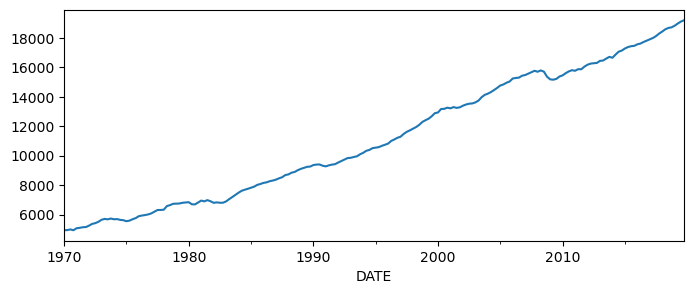

In [31]:
data = pd.read_csv('data7_GDP_Q_real_SA.csv',  header = 0, index_col = 0)
data.index = pd.to_datetime(data.index)
data = data['1970':'2019']
data.columns = ['gdp']
data.gdp.plot(figsize = (8,3))

In [33]:
model_gdp = ARIMA(data.gdp, order =(1,1,1))
res_gdp = model_gdp.fit()
res_gdp.summary()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    gdp   No. Observations:                  200
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1133.803
Date:                Sun, 09 Mar 2025   AIC                           2273.607
Time:                        22:00:39   BIC                           2283.486
Sample:                    01-01-1970   HQIC                          2277.605
                         - 10-01-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9403      0.032     29.056      0.000       0.877       1.004
ma.L1         -0.5901      0.065     -9.053      0.000      -0.718      -0.462
sigma2      5176.8764    385.449     13.431      0.000    4421.410    5932.343
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                62.40
Prob(Q):                              0.81   Prob(JB):                         0.00
Heteroskedasticity (H):               1.55   Skew:                            -0.52
Prob(H) (two-sided):                  0.08   Kurtosis:                         5.53
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [35]:
data

,gdp
DATE,
1970-01-01,4939.759
1970-04-01,4946.770
1970-07-01,4992.357
1970-10-01,4938.857
1971-01-01,5072.996
...,...
2018-10-01,18721.281
2019-01-01,18833.195
2019-04-01,18982.528


In [37]:
train = data.gdp[:180]
test = data.gdp[180:]

In [39]:
model_gdp = ARIMA(train, order =(1,1,1))
res_gdp = model_gdp.fit()

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [41]:
fc = res_gdp.get_forecast(steps = 20).summary_frame()

In [43]:
fc.head()

gdp,mean,mean_se,mean_ci_lower,mean_ci_upper
2015-01-01,17238.629220,74.583425,17092.448392,17384.810048
2015-04-01,17329.151778,125.362376,17083.446037,17574.857520
2015-07-01,17413.287507,177.099567,17066.178733,17760.396280
2015-10-01,17491.487028,230.612778,17039.494289,17943.479768
2016-01-01,17564.169173,285.747446,17004.114471,18124.223875


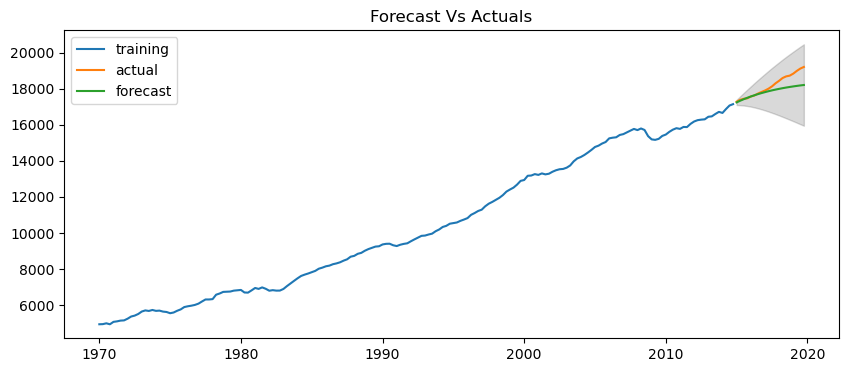

In [45]:
plt.figure(figsize = (10,4))
plt.plot(train, label = 'training')
plt.plot(test, label = 'actual')
plt.plot(fc['mean'], label = 'forecast')
plt.fill_between(fc.index, fc.mean_ci_lower, fc.mean_ci_upper, color = 'k', alpha = 0.15)
plt.title('Forecast Vs Actuals')
plt.legend(loc = 'upper left', fontsize = 10)

In [47]:
def forecast_accuracy(forecast, actual):
    mae = np.mean(np.abs(forecast - actual))
    rmse = np.mean((forecast - actual) ** 2) ** .5
    return({'mae':mae, 'rmse' :rmse})

In [49]:
forecast_accuracy(fc['mean'], test.values)

{'mae': 339.16792023849814, 'rmse': 478.11351046716914}